
Step 1 — 편향 측정 (Bias Measurement)

KuaiRec big_matrix를 분석:
  1) 아이템 인기도 분포 시각화 (long-tail, Lorenz)
  2) 노출 빈도 vs watch_ratio 상관관계
  3) "얼마나 편향돼 있는가" 정량화 (Gini, Pareto)


In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ROOT = Path("/content/drive/MyDrive/Research")

DATA_DIR = ROOT / "KuaiRec/data"
OUT_DIR = ROOT / "KuaiRec/output"

OUT_DIR.mkdir(parents=True, exist_ok=True)

# 한글 깨짐 방지 (환경 맞게 주석 해제)
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# 유틸
def gini_coefficient(x: np.ndarray) -> float:
    "배열 x의 Gini 계수. 0이면 완전 평등, 1에 가까울수록 불평등."
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

In [ ]:
# 1. 데이터 로드

big = pd.read_csv(DATA_DIR / "big_matrix.csv")
print(f"big_matrix:  {big.shape[0]:>10,} rows × {big.shape[1]} cols")
print(f"  unique users: {big['user_id'].nunique():>8,}")
print(f"  unique items: {big['video_id'].nunique():>8,}")
print(f"  watch_ratio:  min={big['watch_ratio'].min():.3f}, "
      f"median={big['watch_ratio'].median():.3f}, "
      f"max={big['watch_ratio'].max():.3f}")

big_matrix:  12,530,806 rows × 8 cols
  unique users:    7,176
  unique items:   10,728
  watch_ratio:  min=0.000, median=0.723, max=573.457


In [ ]:
# 2. 아이템 인기도 분포

item_stats = (
    big.groupby("video_id")
    .agg(
        exposure_count=("user_id", "count"),
        unique_users=("user_id", "nunique"),
        avg_watch_ratio=("watch_ratio", "mean"),
        median_watch_ratio=("watch_ratio", "median"),
    )
    .reset_index()
    .sort_values("exposure_count", ascending=False)
    .reset_index(drop=True)
)

print(f"top item:    {item_stats.iloc[0]['exposure_count']:>10,.0f} exposures")
print(f"median item: {item_stats['exposure_count'].median():>10,.0f} exposures")
print(f"bottom item: {item_stats.iloc[-1]['exposure_count']:>10,.0f} exposures")

# Gini 계수
g = gini_coefficient(item_stats["exposure_count"].values)
print(f"\nGini coefficient (item exposure): {g:.4f}")
print("  (0=완전평등, 1=완전불평등 — 0.6 이상이면 강한 long-tail)")

# Pareto 검증: 상위 X% 아이템이 전체 노출의 몇 %를 차지하는가
print("\nPareto check:")
total_exp = item_stats["exposure_count"].sum()
for pct in [1, 5, 10, 20, 30]:
    top_n = max(int(len(item_stats) * pct / 100), 1)
    share = item_stats.head(top_n)["exposure_count"].sum() / total_exp
    print(f"  top {pct:>2}% items ({top_n:>4} items) → "
          f"{share * 100:5.1f}% of total exposures")

top item:        27,615 exposures
median item:        243 exposures
bottom item:          1 exposures

Gini coefficient (item exposure): 0.6722
  (0=완전평등, 1=완전불평등 — 0.6 이상이면 강한 long-tail)

Pareto check:
  top  1% items ( 107 items) →   6.0% of total exposures
  top  5% items ( 536 items) →  23.3% of total exposures
  top 10% items (1072 items) →  40.7% of total exposures
  top 20% items (2145 items) →  66.4% of total exposures
  top 30% items (3218 items) →  84.7% of total exposures


In [ ]:
# Gini 0.67, top 10%가 41% 차지
# 편향은 확실히 있음


[saved] /content/drive/MyDrive/Research/KuaiRec/output/01_popularity_distribution.png


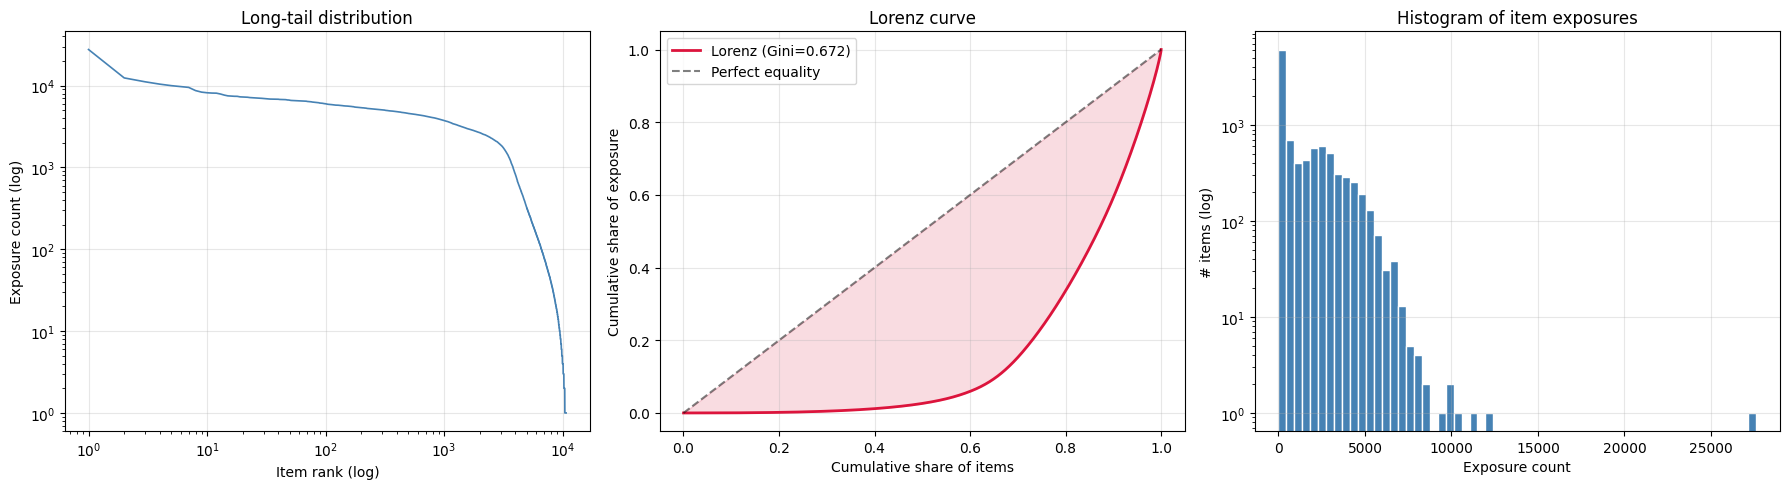

In [ ]:
# 3. 시각화: long-tail / Lorenz / 히스토그램

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rank vs frequency (log-log) — long-tail
ax = axes[0]
ax.plot(np.arange(1, len(item_stats) + 1), item_stats["exposure_count"].values,
        color="steelblue", linewidth=1.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Item rank (log)")
ax.set_ylabel("Exposure count (log)")
ax.set_title("Long-tail distribution")
ax.grid(True, alpha=0.3)

# (b) Lorenz curve
ax = axes[1]
sorted_counts = np.sort(item_stats["exposure_count"].values)
cum_share = np.cumsum(sorted_counts) / sorted_counts.sum()
x = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax.plot(x, cum_share, color="crimson", linewidth=2,
        label=f"Lorenz (Gini={g:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect equality")
ax.fill_between(x, x, cum_share, alpha=0.15, color="crimson")
ax.set_xlabel("Cumulative share of items")
ax.set_ylabel("Cumulative share of exposure")
ax.set_title("Lorenz curve")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# (c) Histogram
ax = axes[2]
ax.hist(item_stats["exposure_count"], bins=60, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Exposure count")
ax.set_ylabel("# items (log)")
ax.set_title("Histogram of item exposures")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "01_popularity_distribution.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '01_popularity_distribution.png'}")

Spearman ρ = -0.2987  (p=6.43e-220)
Pearson  r = -0.0882  (p=5.64e-20)

Quintile analysis:
                     n_items  avg_exposure  avg_watch_ratio  std_watch_ratio
popularity_quintile                                                         
Q1\n(least popular)     2146      9.227400         2.000045         4.374788
Q2                      2145     59.833100         1.139124         1.593180
Q3                      2146    278.078285         0.989276         0.474177
Q4                      2145   1616.061538         0.949848         0.405131
Q5\n(most popular)      2146   3876.726002         0.940138         0.386095

[saved] /content/drive/MyDrive/Research/KuaiRec/output/02_exposure_vs_engagement.png


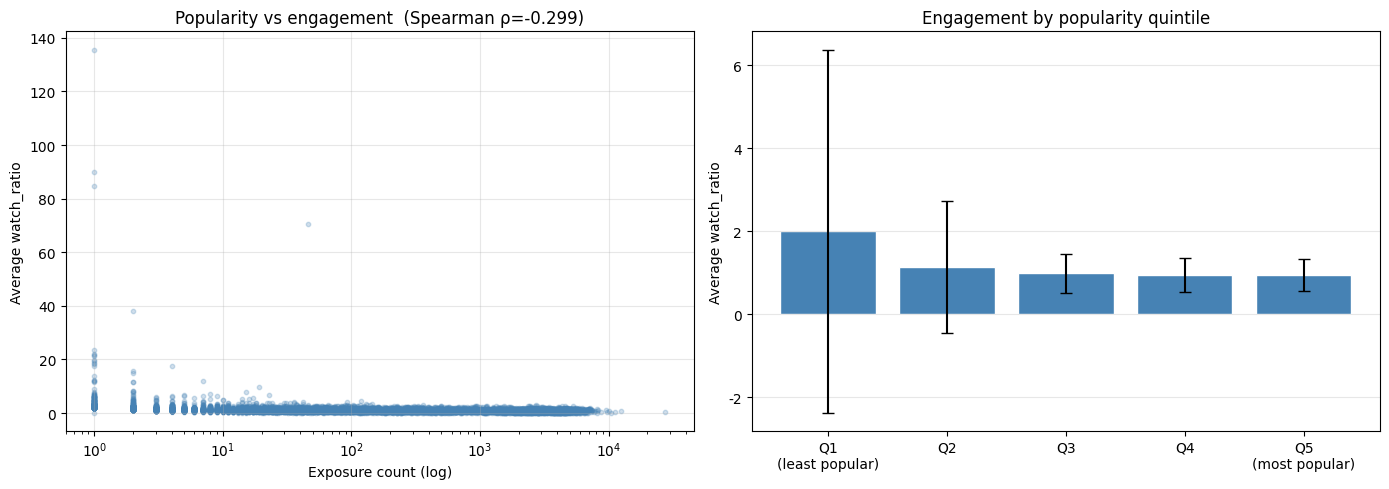

In [ ]:
# 4. 노출 빈도 vs watch_ratio 상관관계

rho, p_rho = spearmanr(item_stats["exposure_count"], item_stats["avg_watch_ratio"])
r, p_r = pearsonr(item_stats["exposure_count"], item_stats["avg_watch_ratio"])
print(f"Spearman ρ = {rho:+.4f}  (p={p_rho:.2e})")
print(f"Pearson  r = {r:+.4f}  (p={p_r:.2e})")

# 5분위 분석
item_stats["popularity_quintile"] = pd.qcut(
    item_stats["exposure_count"].rank(method="first"),
    q=5,
    labels=["Q1\n(least popular)", "Q2", "Q3", "Q4", "Q5\n(most popular)"],
)
qstats = item_stats.groupby("popularity_quintile").agg(
    n_items=("video_id", "count"),
    avg_exposure=("exposure_count", "mean"),
    avg_watch_ratio=("avg_watch_ratio", "mean"),
    std_watch_ratio=("avg_watch_ratio", "std"),
)
print("\nQuintile analysis:")
print(qstats.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(item_stats["exposure_count"], item_stats["avg_watch_ratio"],
           alpha=0.25, s=10, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel("Average watch_ratio")
ax.set_title(f"Popularity vs engagement  (Spearman ρ={rho:+.3f})")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(
    range(len(qstats)),
    qstats["avg_watch_ratio"],
    yerr=qstats["std_watch_ratio"],
    color="steelblue",
    capsize=4,
    edgecolor="white",
)
ax.set_xticks(range(len(qstats)))
ax.set_xticklabels(qstats.index)
ax.set_ylabel("Average watch_ratio")
ax.set_title("Engagement by popularity quintile")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(OUT_DIR / "02_exposure_vs_engagement.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '02_exposure_vs_engagement.png'}")

In [ ]:
# Spearman ρ = −0.30, Pearson r = −0.09
# 인기 있을수록 watch_ratio가 낮아지는 방향
# "추천된 게 인기 있어서가 아니라, 노출돼서 인기 있어진거다"라는 가설을 지지함

# Q1의 평균 노출 9.2번, std 4.37은 평균 2.0보다 2배 이상 크다는 뜻 — 분포가 헝클어져 있음
# 산점도 왼쪽 위에 점 몇 개 (140 근처)가 보이는데 얘네가 평균을 다 끌어올린 것
# 즉, Q1의 2.0은 "Q1이 진짜 더 좋아서"가 아니라 표본이 적은 데서 outlier가 평균을 흔든 것

# 표본이 충분히 모인 분위 안에서는 노출이 4배(278→1616), 14배(278→3877) 늘어나도 평균 watch_ratio는 거의 안 변함
# 즉, "인기는 노출의 결과지 선호의 결과가 아니다"

Step 1b — watch_ratio capping 후 편향 측정 재실행

이전 결과의 Q1 outlier 문제를 해소하기 위해 watch_ratio에 상한을 두고 quintile 분석과 상관관계를 다시 계산

big_matrix: 12,530,806 rows
watch_ratio (raw): min=0.000, median=0.723, max=573.457
watch_ratio > 2.0 인 비율: 7.47%
watch_ratio > 5.0 인 비율: 0.92%
   cap  spearman  pearson  Q1_avg_wr  Q1_std_wr  Q3_avg_wr  Q5_avg_wr  Q5/Q3_ratio
no cap   -0.2987  -0.0882      2.000      4.375      0.989      0.940        0.950
   1.0   -0.2076  -0.1234      0.768      0.213      0.652      0.643        0.987
   2.0   -0.2811  -0.2110      1.234      0.496      0.858      0.806        0.940
   3.0   -0.3086  -0.2256      1.449      0.688      0.911      0.851        0.934
   5.0   -0.3176  -0.2189      1.606      0.934      0.941      0.883        0.938
  10.0   -0.3164  -0.1984      1.732      1.291      0.963      0.908        0.943
[BEFORE — no cap]
          n_items  avg_exposure  avg_watch_ratio  std_watch_ratio
quintile                                                         
Q1           2146         9.227            2.000            4.375
Q2           2145        59.833            1.139           

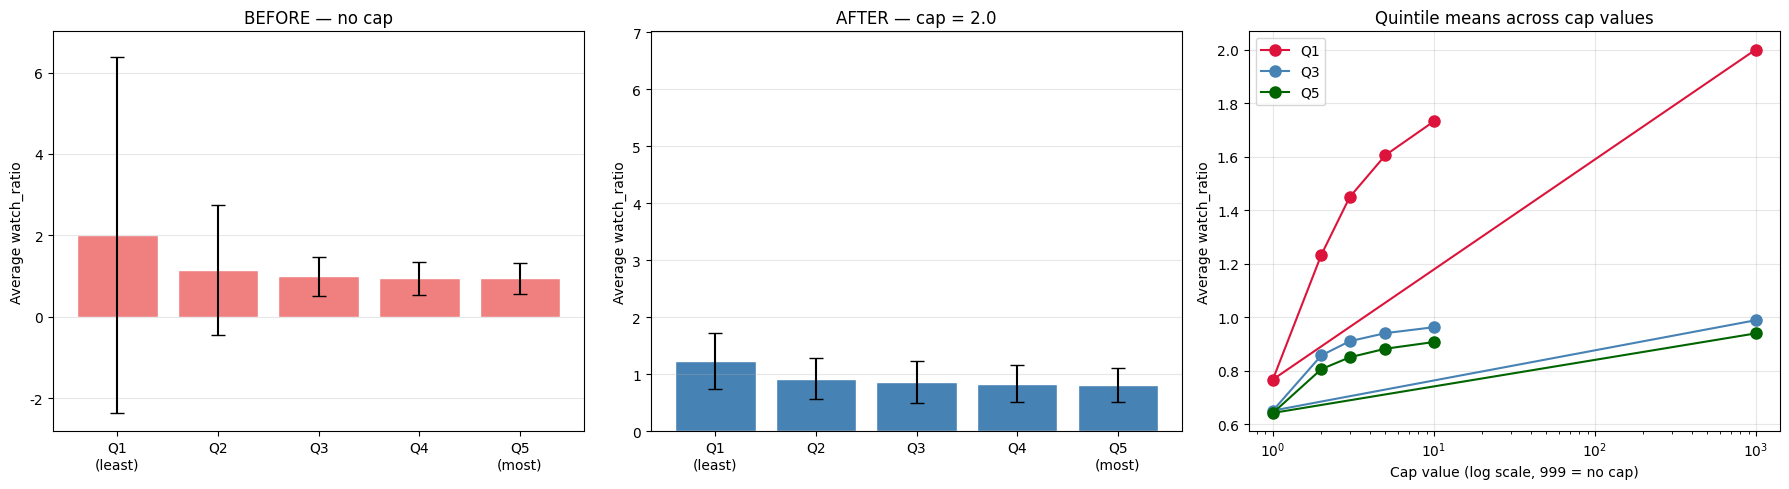

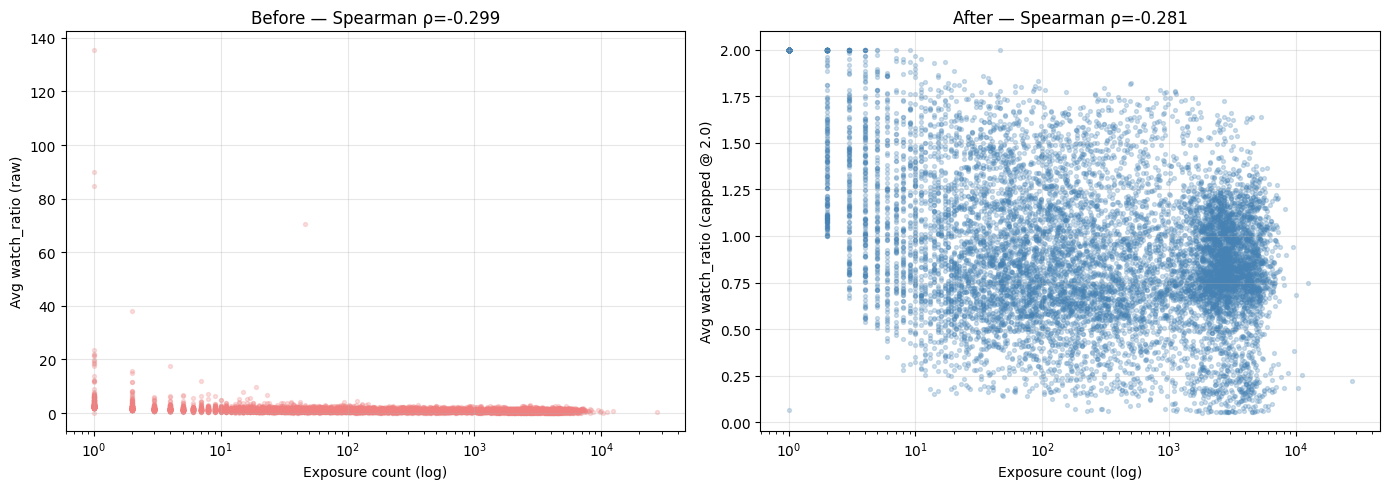

In [ ]:
DEFAULT_CAP = 2.0  # 메인 cap 값
SENSITIVITY_CAPS = [None, 1.0, 2.0, 3.0, 5.0, 10.0]  # 비교용


def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)


# 1. 데이터 로드

big = pd.read_csv(DATA_DIR / "big_matrix.csv")
print(f"big_matrix: {len(big):,} rows")
print(f"watch_ratio (raw): min={big['watch_ratio'].min():.3f}, "
      f"median={big['watch_ratio'].median():.3f}, "
      f"max={big['watch_ratio'].max():.3f}")
print(f"watch_ratio > 2.0 인 비율: "
      f"{(big['watch_ratio'] > 2.0).mean() * 100:.2f}%")
print(f"watch_ratio > 5.0 인 비율: "
      f"{(big['watch_ratio'] > 5.0).mean() * 100:.2f}%")

# 2. cap별로 item_stats 재계산

def compute_item_stats(big_df: pd.DataFrame, cap: float | None) -> pd.DataFrame:
    """주어진 cap으로 watch_ratio를 clipping해 아이템 단위 집계."""
    wr = big_df["watch_ratio"] if cap is None else big_df["watch_ratio"].clip(upper=cap)
    tmp = big_df[["user_id", "video_id"]].assign(watch_ratio=wr.values)
    return (
        tmp.groupby("video_id")
        .agg(
            exposure_count=("user_id", "count"),
            avg_watch_ratio=("watch_ratio", "mean"),
            median_watch_ratio=("watch_ratio", "median"),
        )
        .reset_index()
        .sort_values("exposure_count", ascending=False)
        .reset_index(drop=True)
    )


def quintile_summary(stats: pd.DataFrame) -> pd.DataFrame:
    stats = stats.copy()
    stats["quintile"] = pd.qcut(
        stats["exposure_count"].rank(method="first"),
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    )
    return stats.groupby("quintile").agg(
        n_items=("video_id", "count"),
        avg_exposure=("exposure_count", "mean"),
        avg_watch_ratio=("avg_watch_ratio", "mean"),
        std_watch_ratio=("avg_watch_ratio", "std"),
    )



# 3. Sensitivity: 여러 cap에 대해 핵심 지표 비교

rows = []
qtables = {}
for cap in SENSITIVITY_CAPS:
    s = compute_item_stats(big, cap)
    rho, _ = spearmanr(s["exposure_count"], s["avg_watch_ratio"])
    r, _ = pearsonr(s["exposure_count"], s["avg_watch_ratio"])
    q = quintile_summary(s)
    qtables[cap] = q
    rows.append({
        "cap": "no cap" if cap is None else f"{cap:.1f}",
        "spearman": round(rho, 4),
        "pearson": round(r, 4),
        "Q1_avg_wr": round(q.loc["Q1", "avg_watch_ratio"], 3),
        "Q1_std_wr": round(q.loc["Q1", "std_watch_ratio"], 3),
        "Q3_avg_wr": round(q.loc["Q3", "avg_watch_ratio"], 3),
        "Q5_avg_wr": round(q.loc["Q5", "avg_watch_ratio"], 3),
        "Q5/Q3_ratio": round(
            q.loc["Q5", "avg_watch_ratio"] / q.loc["Q3", "avg_watch_ratio"], 3
        ),
    })

sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

# 4. 메인 cap (=DEFAULT_CAP) 결과 상세

stats_raw = compute_item_stats(big, None)
stats_cap = compute_item_stats(big, DEFAULT_CAP)

q_raw = quintile_summary(stats_raw)
q_cap = quintile_summary(stats_cap)

print("[BEFORE — no cap]")
print(q_raw.round(3).to_string())
print("\n[AFTER — cap=2.0]")
print(q_cap.round(3).to_string())

rho_cap, _ = spearmanr(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"])
r_cap, _ = pearsonr(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"])
print(f"\nAfter cap=2.0:  Spearman ρ = {rho_cap:+.4f}, Pearson r = {r_cap:+.4f}")


# 5. 시각화: Before vs After quintile bars

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(5)
labels = ["Q1\n(least)", "Q2", "Q3", "Q4", "Q5\n(most)"]

# (a) Before
ax = axes[0]
ax.bar(x, q_raw["avg_watch_ratio"], yerr=q_raw["std_watch_ratio"],
       color="lightcoral", capsize=5, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average watch_ratio")
ax.set_title("BEFORE — no cap")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))

# (b) After
ax = axes[1]
ax.bar(x, q_cap["avg_watch_ratio"], yerr=q_cap["std_watch_ratio"],
       color="steelblue", capsize=5, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Average watch_ratio")
ax.set_title(f"AFTER — cap = {DEFAULT_CAP}")
ax.grid(True, alpha=0.3, axis="y")

# y축 두 그래프 통일
ymax = max(
    (q_raw["avg_watch_ratio"] + q_raw["std_watch_ratio"]).max(),
    (q_cap["avg_watch_ratio"] + q_cap["std_watch_ratio"]).max(),
) * 1.1
axes[0].set_ylim(top=ymax)
axes[1].set_ylim(top=ymax)

# (c) cap별 Q1, Q3, Q5 trend
ax = axes[2]
caps_x = [c if c is not None else 999 for c in SENSITIVITY_CAPS]
for q_name, color in [("Q1", "crimson"), ("Q3", "steelblue"), ("Q5", "darkgreen")]:
    vals = [qtables[c].loc[q_name, "avg_watch_ratio"] for c in SENSITIVITY_CAPS]
    ax.plot(caps_x, vals, "o-", color=color, label=q_name, markersize=8)
ax.set_xscale("log")
ax.set_xlabel("Cap value (log scale, 999 = no cap)")
ax.set_ylabel("Average watch_ratio")
ax.set_title("Quintile means across cap values")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "02b_quintile_capped.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '02b_quintile_capped.png'}")


# 6. capped scatter (전체 데이터에서)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(stats_raw["exposure_count"], stats_raw["avg_watch_ratio"],
           alpha=0.25, s=8, color="lightcoral")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel("Avg watch_ratio (raw)")
ax.set_title(f"Before — Spearman ρ={spearmanr(stats_raw['exposure_count'], stats_raw['avg_watch_ratio'])[0]:+.3f}")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(stats_cap["exposure_count"], stats_cap["avg_watch_ratio"],
           alpha=0.25, s=8, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Exposure count (log)")
ax.set_ylabel(f"Avg watch_ratio (capped @ {DEFAULT_CAP})")
ax.set_title(f"After — Spearman ρ={rho_cap:+.3f}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "02c_scatter_capped.png", dpi=120)
print(f"[saved] {OUT_DIR / '02c_scatter_capped.png'}")


# 7. 결과 저장

stats_cap.to_csv(OUT_DIR / "item_stats_capped.csv", index=False)
sens.to_csv(OUT_DIR / "cap_sensitivity.csv", index=False)
print(f"[saved] {OUT_DIR / 'item_stats_capped.csv'}")
print(f"[saved] {OUT_DIR / 'cap_sensitivity.csv'}")

In [ ]:
# cap값이 다르다는 게 무슨 의미인가?
# watch_ratio를 어디서 자르는지가 무슨 행동을 측정하느냐

# cap=1.0: 1을 넘는 값은 다 1로 자름 → "한 번 끝까지 봤는가?"만 봄, 두 번 보든 열 번 보든 똑같이 1
# cap=2.0: 1.0~2.0 구간은 살아남음 → "끝까지 봤는가? + 한 번 더 봤는가?"까지 봄, 그 이상의 반복 시청은 다 2로 잘림
# cap 없음: 반복 시청 횟수가 그대로 반영됨, 같은 영상 100번 보면 watch_ratio=100

# 즉 cap을 1.0 → 2.0으로 올린다는 건 "반복 시청 신호를 분석에 더 많이 넣는다"는 뜻

In [ ]:
# Spearman: -0.299 → -0.281 / 분포 변형에 robust → cap별로 큰 차이 없음
# Pearson" -0.088 → -0.211 / cap에 따라 크게 흔들림

# Q1 std: 4.375 → 0.495 / 9배 감소 ->cap이 내려갈수록 Q1의 outlier가 정리됨
# Q1 평균: 2.001 → 1.234 / 거품 빠짐

# Q1: 1.234 → Q2: 0.919 → Q3: 0.858 → Q4: 0.833 → Q5: 0.806
# 단조 감소 / 노출이 많을수록 평균 watch_ratio가 오히려 낮다 !

In [ ]:
# cap=1.0 vs cap=2.0
# cap=1.0: Q5/Q3 = 0.986 / "한 번 끝까지 보는 비율"은 인기 영상이나 중간 인기 영상이나 비슷
# cap=2.0: Q5/Q3 = 0.940 / 반복 시청은 Q3(중간 인기) 영상에서 Q5(최상위 인기) 영상보다 더 자주 일어남

# 완전 시청만 보면 Q5와 Q3가 비슷
# 반복 시청까지 포함하면 Q3(중간 인기)가 Q5(상위 인기)를 앞섬
# 즉, long-tail에 가까운 아이템일수록 "푹 빠지는 유저"의 비율이 높다

In [ ]:
# 5. 사이드 — 유저 단위 편향도 (참고용)

user_activity = big.groupby("user_id").size()
g_user = gini_coefficient(user_activity.values)
print(f"User-side Gini: {g_user:.4f}")
print(f"  active heavy user (top 10%) sees "
      f"{user_activity.quantile(0.9):,.0f}+ items")
print(f"  median user sees {user_activity.median():,.0f} items")

User-side Gini: 0.3179
  active heavy user (top 10%) sees 2,912+ items
  median user sees 1,846 items


In [ ]:
# 6. 결과 저장

item_stats.drop(columns=["popularity_quintile"]).to_csv(
    OUT_DIR / "item_stats.csv", index=False
)
print(f"[saved] {OUT_DIR / 'item_stats.csv'}")

# 한 줄 summary
summary = pd.DataFrame(
    [{
        "n_users": big["user_id"].nunique(),
        "n_items": big["video_id"].nunique(),
        "n_interactions": len(big),
        "item_gini": round(g, 4),
        "user_gini": round(g_user, 4),
        "spearman_pop_vs_watch": round(rho, 4),
        "pearson_pop_vs_watch": round(r, 4),
        "top10pct_items_share": round(
            item_stats.head(int(len(item_stats) * 0.1))["exposure_count"].sum()
            / total_exp,
            4,
        ),
    }]
)
summary.to_csv(OUT_DIR / "bias_summary.csv", index=False)
print(f"[saved] {OUT_DIR / 'bias_summary.csv'}")
print("\n" + summary.T.to_string())

[saved] /content/drive/MyDrive/Research/KuaiRec/output/item_stats.csv
[saved] /content/drive/MyDrive/Research/KuaiRec/output/bias_summary.csv

                                  0
n_users                7.176000e+03
n_items                1.072800e+04
n_interactions         1.253081e+07
item_gini              6.722000e-01
user_gini              3.179000e-01
spearman_pop_vs_watch -3.164000e-01
pearson_pop_vs_watch  -1.984000e-01
top10pct_items_share   4.069000e-01


In [ ]:
big.groupby("video_id").agg(
    duration=("video_duration", "mean"),
    exposure=("user_id", "count"),
).corr()

# exposure ↔ duration 상관이 약함 (|ρ| < 0.2)

,duration,exposure
duration,1.000000,0.092988
exposure,0.092988,1.000000


Step 2 — Propensity Score 계산

In [ ]:
# small_matrix의 (user × item) 영역은 big_matrix에서 통째로 제외돼 있음.
# → small_matrix는 propensity 계산용이 아니라 Step 3 평가용(unbiased GT).
# → propensity는 big_matrix 단독으로 추정

#  popularity 기반:  p_i ∝ pop_i^α
# α를 [0.3, 0.5, 0.7, 1.0]에 대해 sweep, 0.5가 표준값.

In [ ]:
# 설정

ALPHAS = [0.3, 0.5, 0.7, 1.0]
DEFAULT_ALPHA = 0.5
CLIP_MIN = 0.01
CLIP_MAX = 1.0

def section(title: str) -> None:
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

In [ ]:
# 1. 데이터 로드

small = pd.read_csv(DATA_DIR / "small_matrix.csv")

n_users = big["user_id"].nunique()
n_items_big = big["video_id"].nunique()
small_items = set(small["video_id"].unique())

print(f"big:   {len(big):>10,} rows  ({n_users:,} users × {n_items_big:,} items)")
print(f"small: {len(small):>10,} rows  (eval set: {len(small_items):,} items)")

big:   12,530,806 rows  (7,176 users × 10,728 items)
small:  4,676,570 rows  (eval set: 3,327 items)


In [ ]:
# 2. popularity 기반 propensity

# 아이템별 노출 횟수 (big_matrix 전체)
item_pop = big.groupby("video_id").size().rename("exposure_count")
print(f"item coverage in big: {len(item_pop):,} / {n_items_big:,}")

# α 값별로 propensity 계산
def compute_p_alpha(pop: pd.Series, alpha: float) -> pd.Series:
    """p_i ∝ pop_i^α, max-normalize 후 clipping."""
    raw = pop.values.astype(float) ** alpha
    return pd.Series(
        np.clip(raw / raw.max(), CLIP_MIN, CLIP_MAX),
        index=pop.index,
        name=f"p_alpha_{alpha}",
    )

p_dict = {alpha: compute_p_alpha(item_pop, alpha) for alpha in ALPHAS}

# 단순 빈도 기반 (참고용 baseline)
p_naive = (item_pop / n_users).clip(CLIP_MIN, CLIP_MAX).rename("p_naive")

# small_items 한정 통계
print(f"\nDistribution on small_items (n={len(small_items):,}, 평가 대상):")
header = f"  {'method':<14} {'min':>7} {'25%':>7} {'med':>7} {'75%':>7} {'max':>7}"
print(header)
for alpha in ALPHAS:
    s = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    q = s.quantile([0.0, 0.25, 0.5, 0.75, 1.0])
    print(f"  α={alpha:<10}    {q.iloc[0]:>7.4f} {q.iloc[1]:>7.4f} "
          f"{q.iloc[2]:>7.4f} {q.iloc[3]:>7.4f} {q.iloc[4]:>7.4f}")

item coverage in big: 10,728 / 10,728

Distribution on small_items (n=3,327, 평가 대상):
  method             min     25%     med     75%     max
  α=0.3            0.0705  0.4646  0.5050  0.5584  1.0000
  α=0.5            0.0120  0.2787  0.3202  0.3787  1.0000
  α=0.7            0.0100  0.1672  0.2031  0.2568  1.0000
  α=1.0            0.0100  0.0777  0.1026  0.1434  1.0000


In [ ]:
# 3. Sanity check: quintile별 propensity 단조 증가 여부

# popularity quintile (small_items 내에서)
small_pop = item_pop.loc[item_pop.index.isin(small_items)].copy()
quintile = pd.qcut(
    small_pop.rank(method="first"), q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
)
quintile_df = pd.DataFrame({"pop": small_pop, "quintile": quintile})

q_compare = pd.DataFrame(index=["Q1", "Q2", "Q3", "Q4", "Q5"])
for alpha in ALPHAS:
    p = p_dict[alpha].loc[
    p_dict[alpha].index.intersection(small_items)
]
    q_compare[f"α={alpha}"] = quintile_df.assign(p=p).groupby("quintile")["p"].mean()

print(q_compare.round(4).to_string())

     α=0.3   α=0.5   α=0.7   α=1.0
Q1  0.4013  0.2217  0.1235  0.0520
Q2  0.4733  0.2875  0.1747  0.0828
Q3  0.5049  0.3202  0.2031  0.1026
Q4  0.5454  0.3643  0.2433  0.1329
Q5  0.6043  0.4327  0.3102  0.1890


In [ ]:
# 4. IPW weight diagnostics — α 선택의 핵심 정보

ipw_stats = []
for alpha in ALPHAS:
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    w = 1.0 / p
    ipw_stats.append({
        "alpha": alpha,
        "weight_mean": w.mean(),
        "weight_median": w.median(),
        "weight_max": w.max(),
        "weight_p99": w.quantile(0.99),
        "weight_p95/p50": w.quantile(0.95) / w.quantile(0.50),
    })
ipw_df = pd.DataFrame(ipw_stats)
print(ipw_df.round(3).to_string(index=False))

 alpha  weight_mean  weight_median  weight_max  weight_p99  weight_p95/p50
   0.3        2.047          1.980      14.182       3.654           1.294
   0.5        3.433          3.123      83.089       8.668           1.537
   0.7        5.740          4.924     100.000      20.562           1.825
   1.0       11.977          9.751     100.000      75.133           2.362


In [ ]:
# α↓ → propensity가 평탄해짐 → weight도 평탄 → 학습 안정 / 보정 약함
# α↑ → propensity 가파름 → weight 분산 큼 → 학습 불안정 / 보정 강함
# p95/p50 비율: 가중치 분산의 직관적 지표 (모두 10 이하 안전)


[saved] /content/drive/MyDrive/Research/KuaiRec/output/04_propensity_alpha.png


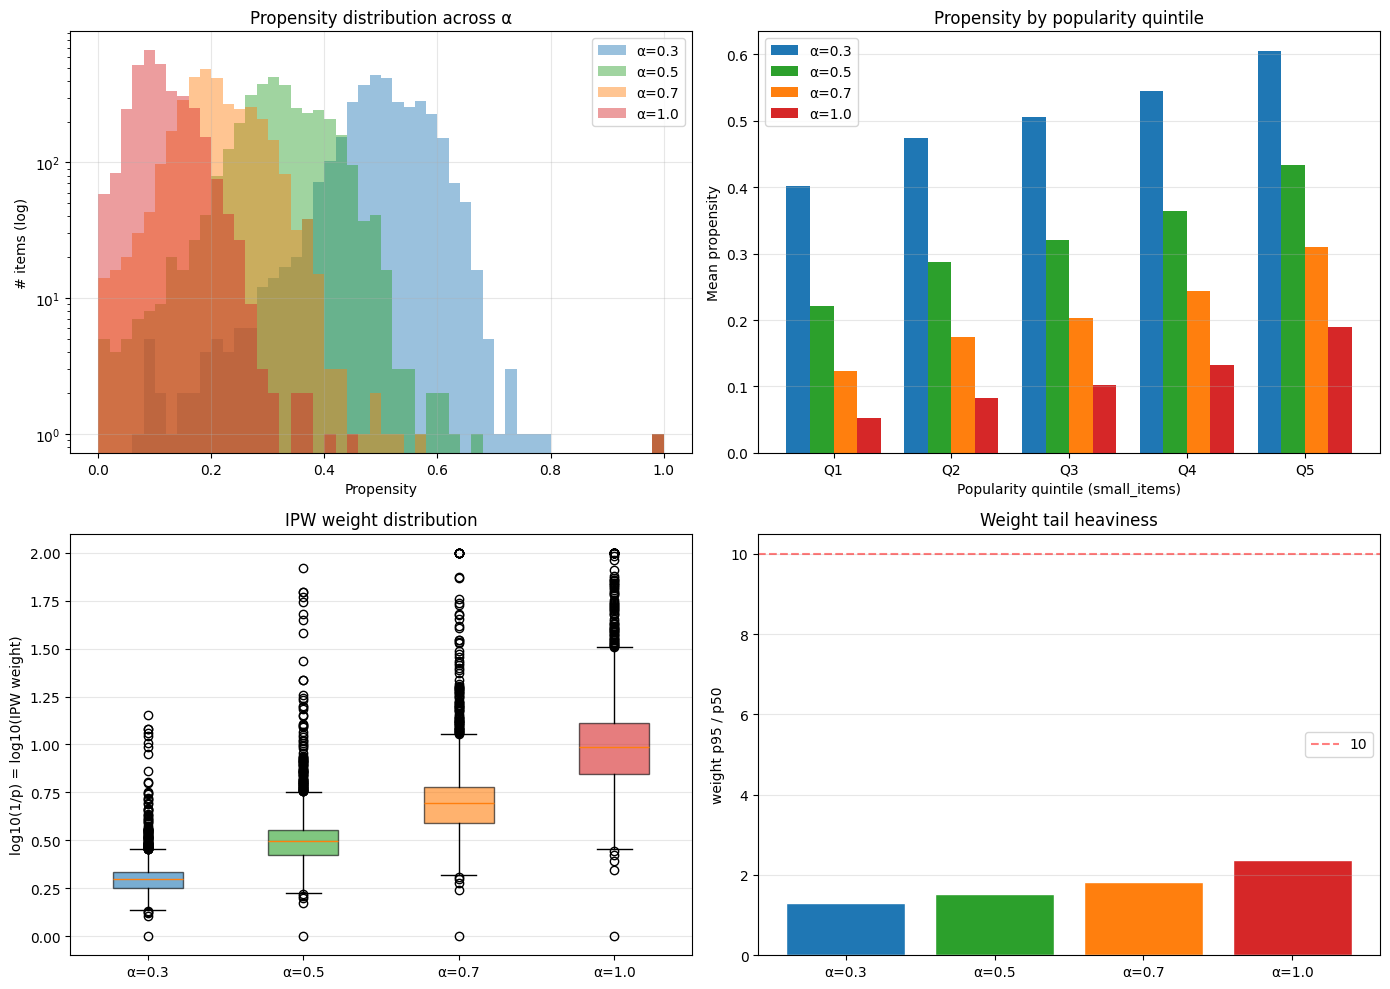

In [ ]:
# 5. 시각화 (4-panel)

warnings.filterwarnings("ignore")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

# (a) α별 propensity 분포
ax = axes[0, 0]
bins = np.linspace(0, 1, 51)
for alpha, c in zip(ALPHAS, colors):
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    ax.hist(p, bins=bins, alpha=0.45, label=f"α={alpha}", color=c)
ax.set_yscale("log")
ax.set_xlabel("Propensity")
ax.set_ylabel("# items (log)")
ax.set_title("Propensity distribution across α")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) quintile별 평균 propensity
ax = axes[0, 1]
x = np.arange(5)
width = 0.2
for i, alpha in enumerate(ALPHAS):
    ax.bar(x + (i - 1.5) * width, q_compare[f"α={alpha}"], width,
           label=f"α={alpha}", color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
ax.set_xlabel("Popularity quintile (small_items)")
ax.set_ylabel("Mean propensity")
ax.set_title("Propensity by popularity quintile")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# (c) IPW weight 분포 (boxplot, log scale)
ax = axes[1, 0]
data = []
for alpha in ALPHAS:
    p = p_dict[alpha].loc[p_dict[alpha].index.isin(small_items)]
    data.append(np.log10(1.0 / p))
bp = ax.boxplot(data, tick_labels=[f"α={a}" for a in ALPHAS],
                showfliers=True, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_ylabel("log10(1/p) = log10(IPW weight)")
ax.set_title("IPW weight distribution")
ax.grid(True, alpha=0.3, axis="y")

# (d) p95/p50 ratio - 분산 비교
ax = axes[1, 1]
ax.bar(range(len(ALPHAS)), ipw_df["weight_p95/p50"],
       color=colors, edgecolor="white")
ax.set_xticks(range(len(ALPHAS)))
ax.set_xticklabels([f"α={a}" for a in ALPHAS])
ax.set_ylabel("weight p95 / p50")
ax.set_title("Weight tail heaviness")
ax.axhline(10, color="red", linestyle="--", alpha=0.5, label="10")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(OUT_DIR / "04_propensity_alpha.png", dpi=120)
print(f"\n[saved] {OUT_DIR / '04_propensity_alpha.png'}")

In [ ]:
# (a) α=0.3은 평균 0.5 근처에 모여 있음
# 즉 거의 균등 가중치라 IPW 보정이 약함
# α↑할수록 분포가 왼쪽(0 근처)으로 끌려가고 long-tail item에 큰 weight가 붙음
# 즉, "low propensity item에 IPS 보정으로 더 많이 올려주자"

# (b) 모든 α에서 깔끔하게 단조 증가
# 추천 시스템이 인기 있는 아이템을 더 많이 노출했고, 우리 propensity가 그걸 잘 포착했음

In [ ]:
# 6. 결과 저장

# (a) Step 3에서 바로 쓸 default propensity (모든 big items 포함)
default = p_dict[DEFAULT_ALPHA].rename("propensity")
out_main = pd.DataFrame({
    "video_id": default.index,
    "exposure_count": item_pop.loc[default.index].values,
    "propensity": default.values,
    "in_small_items": [vid in small_items for vid in default.index],
})
out_main.to_csv(OUT_DIR / "propensity_final.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_final.csv'}  "
      f"(α={DEFAULT_ALPHA}, n={len(out_main):,} items)")

# (b) α별 비교 테이블 (small_items 한정)
sweep = pd.DataFrame({"video_id": list(small_items & set(item_pop.index))})
sweep["exposure_count"] = sweep["video_id"].map(item_pop)
for alpha in ALPHAS:
    sweep[f"p_alpha_{alpha}"] = sweep["video_id"].map(p_dict[alpha])
sweep = sweep.sort_values("exposure_count", ascending=False).reset_index(drop=True)
sweep.to_csv(OUT_DIR / "propensity_alpha_sweep.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_alpha_sweep.csv'}")

# (c) α 진단 통계
ipw_df.to_csv(OUT_DIR / "propensity_alpha_diagnostics.csv", index=False)
print(f"[saved] {OUT_DIR / 'propensity_alpha_diagnostics.csv'}")

[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_final.csv  (α=0.5, n=10,728 items)
[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_alpha_sweep.csv
[saved] /content/drive/MyDrive/Research/KuaiRec/output/propensity_alpha_diagnostics.csv


Step 3 — IPS-debiased BPR

Step 2의 propensity score를 BPR loss의 sample weight로 사용
α를 [0.0, 0.5, 0.7, 1.0]로 sweep, 같은 셋업에서 학습/평가하여 비교

  α=0.0 → 무보정 baseline (표준 BPR)

  α>0   → IPS-debiased (low-popularity item에 큰 weight)

평가 지표:

  Recall@K, NDCG@K   — 정확도

  Coverage@K         — long-tail 추천력 (top-K에 등장한 unique item 비율)

  Gini@K             — 추천 분포 불평등도

In [ ]:
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [ ]:
# 1. Config

class Config:
    DATA_DIR = Path("/content/drive/MyDrive/Research/KuaiRec/data")
    OUT_DIR = Path("/content/drive/MyDrive/Research/KuaiRec/output")

    # 학습 데이터 정의
    POS_THRESHOLD = 1.0          # watch_ratio >= 1.0 = 긍정 신호
    EVAL_THRESHOLD = 1.0         # 평가 시 ground truth 기준

    # MF 모델
    EMBED_DIM = 64
    REG = 1e-5                   # L2 regularization

    # 학습
    LR = 1e-3
    BATCH_SIZE = 8192
    EPOCHS = 10
    NUM_WORKERS = 0              # Colab은 0 권장

    # IPS
    ALPHAS = [0.0, 0.5, 0.7, 1.0]
    PROPENSITY_CLIP_MIN = 0.01
    NORMALIZE_WEIGHTS = True     # batch 내 평균 weight = 1로 정규화

    # 평가
    KS = [10, 20, 50]
    EVAL_BATCH = 256

    # 데모 모드 — 파이프라인 sanity check용
    DEMO = False                 # True : 200K pair × 3 epoch로 빠르게 파이프라인만 검증
    DEMO_SAMPLE = 200_000
    DEMO_EPOCHS = 3

    SEED = 42


cfg = Config()
cfg.OUT_DIR.mkdir(exist_ok=True)
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}  |  DEMO mode: {cfg.DEMO}")

device: cuda  |  DEMO mode: False


In [ ]:
# 2. Data loading & preprocessing

def load_data():
    print("Loading data...")
    big = pd.read_csv(cfg.DATA_DIR / "big_matrix.csv",
                      usecols=["user_id", "video_id", "watch_ratio"])
    small = pd.read_csv(cfg.DATA_DIR / "small_matrix.csv",
                        usecols=["user_id", "video_id", "watch_ratio"])
    print(f"  big:   {len(big):,} rows")
    print(f"  small: {len(small):,} rows")
    return big, small


def build_mappings(big):
    """user_id, video_id를 0-indexed contiguous int로 매핑."""
    user2idx = {u: i for i, u in enumerate(sorted(big["user_id"].unique()))}
    item2idx = {v: i for i, v in enumerate(sorted(big["video_id"].unique()))}
    return user2idx, item2idx


def build_train_pairs(big, user2idx, item2idx, threshold):
    """watch_ratio 기반 positive pair 추출 + 중복 제거."""
    pos = big[big["watch_ratio"] >= threshold]
    pos = pos.drop_duplicates(["user_id", "video_id"])
    u = pos["user_id"].map(user2idx).values
    i = pos["video_id"].map(item2idx).values
    return np.stack([u, i], axis=1).astype(np.int64)


def build_user_positives(pairs, n_users):
    """user → positive item set (음성 샘플링 시 제외용)."""
    user_pos = [set() for _ in range(n_users)]
    for u, i in pairs:
        user_pos[u].add(i)
    return user_pos

In [ ]:
# 3. BPR Dataset

class BPRDataset(Dataset):
    """(user, pos_item, neg_item) triplet — neg는 매 epoch 새로 샘플."""

    def __init__(self, pairs, user_pos, n_items):
        self.pairs = pairs
        self.user_pos = user_pos
        self.n_items = n_items

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        u, i = self.pairs[idx]
        # 음성 샘플 (rejection)
        while True:
            j = np.random.randint(self.n_items)
            if j not in self.user_pos[u]:
                break
        return int(u), int(i), int(j)

In [ ]:
# 4. Model — BPR-MF (item bias 포함, user bias는 BPR에서 상쇄)

class BPRMF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        self.item_bias = nn.Embedding(n_items, 1)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, u, i, j):
        eu = self.user_emb(u)
        ei = self.item_emb(i)
        ej = self.item_emb(j)
        bi = self.item_bias(i).squeeze(-1)
        bj = self.item_bias(j).squeeze(-1)
        s_pos = (eu * ei).sum(-1) + bi
        s_neg = (eu * ej).sum(-1) + bj
        return s_pos, s_neg, eu, ei, ej

    @torch.no_grad()
    def score_users(self, u_idx):
        """평가용: 주어진 user들에 대해 모든 item score 반환 [B, N_items]."""
        eu = self.user_emb(u_idx)
        scores = eu @ self.item_emb.weight.T + self.item_bias.weight.squeeze(-1)
        return scores


In [ ]:
# 5. IPS propensity tensor (α별로 다시 계산)

def build_propensity(item_pop_count, alpha):
    """item_pop_count(numpy)에서 α 적용한 propensity tensor 생성."""
    if alpha == 0.0:
        # 보정 없음 → uniform 1.0 (=무가중)
        return np.ones_like(item_pop_count, dtype=np.float32)
    raw = item_pop_count.astype(np.float64) ** alpha
    p = raw / raw.max()
    p = np.clip(p, cfg.PROPENSITY_CLIP_MIN, 1.0)
    return p.astype(np.float32)

In [ ]:
# 6. Training loop

def train_model(model, loader, p_tensor, epochs, lr, reg, normalize_weights):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        n_batches = 0
        pbar = tqdm(loader, desc=f"  epoch {epoch+1:>2}/{epochs}", leave=False)
        for u, i, j in pbar:
            u = u.to(device)
            i = i.to(device)
            j = j.to(device)

            s_pos, s_neg, eu, ei, ej = model(u, i, j)
            diff = s_pos - s_neg

            # IPS weight (positive item의 1/p)
            w = 1.0 / p_tensor[i]
            if normalize_weights:
                w = w / w.mean()  # batch 평균 1로 정규화 → loss scale 일정

            # BPR loss with IPS weight
            loss_bpr = -(w * torch.nn.functional.logsigmoid(diff)).mean()
            # L2 reg (batch 안의 임베딩에만)
            loss_reg = reg * (eu.pow(2).sum() + ei.pow(2).sum() + ej.pow(2).sum())
            loss = loss_bpr + loss_reg

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = total_loss / max(n_batches, 1)
        history.append(avg_loss)
        print(f"    epoch {epoch+1}: loss = {avg_loss:.4f}")
    return history

In [ ]:
# 7. Evaluation

def gini(x: np.ndarray) -> float:
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def evaluate_model(model, small, user2idx, item2idx, small_items_idx,
                   user_pos_train, ks, threshold):
    """small_matrix를 unbiased ground truth로 사용해 평가."""
    model.eval()

    # ground truth: user → set of item idx with watch_ratio >= threshold
    gt_pos = small[small["watch_ratio"] >= threshold]
    user_gt = {}
    for uid, group in gt_pos.groupby("user_id"):
        if uid not in user2idx:
            continue
        u = user2idx[uid]
        items = {item2idx[v] for v in group["video_id"] if v in item2idx}
        if items:
            user_gt[u] = items

    eval_users = sorted(user_gt.keys())
    print(f"  평가 대상 user: {len(eval_users):,}")
    if not eval_users:
        return {}

    # small_items 마스크 (평가 시 small_items에 한정해서 ranking)
    small_mask = torch.zeros(len(item2idx), dtype=torch.bool, device=device)
    small_mask[torch.tensor(small_items_idx, device=device)] = True

    metrics = {f"recall@{k}": [] for k in ks}
    metrics.update({f"ndcg@{k}": [] for k in ks})
    rec_counts = {k: Counter() for k in ks}

    max_k = max(ks)
    with torch.no_grad():
        for start in tqdm(range(0, len(eval_users), cfg.EVAL_BATCH),
                          desc="  eval", leave=False):
            batch_u = eval_users[start:start + cfg.EVAL_BATCH]
            u_t = torch.tensor(batch_u, device=device)
            scores = model.score_users(u_t)              # [B, N_items]

            # small_items 외엔 -inf로 마스킹 (rank에서 제외)
            scores[:, ~small_mask] = -1e9

            # 학습에서 본 item 제외 (leakage 방지)
            for bi, u in enumerate(batch_u):
                if u in user_pos_train:
                    train_items = list(user_pos_train[u])
                    if train_items:
                        scores[bi, train_items] = -1e9

            # top-max_k 한 번에 뽑고 k별로 잘라 씀
            _, topk_idx = scores.topk(max_k, dim=1)
            topk_idx = topk_idx.cpu().numpy()

            for bi, u in enumerate(batch_u):
                gt = user_gt[u]
                rec_full = topk_idx[bi]
                for k in ks:
                    rec = rec_full[:k]
                    hits = [r for r in rec if r in gt]
                    # Recall@k
                    metrics[f"recall@{k}"].append(len(hits) / len(gt))
                    # NDCG@k
                    dcg = sum(1.0 / np.log2(rank + 2)
                              for rank, r in enumerate(rec) if r in gt)
                    idcg = sum(1.0 / np.log2(rank + 2)
                               for rank in range(min(k, len(gt))))
                    metrics[f"ndcg@{k}"].append(dcg / idcg if idcg > 0 else 0.0)
                    rec_counts[k].update(rec.tolist())

    out = {m: float(np.mean(v)) for m, v in metrics.items()}

    # Coverage@k, Gini@k (small_items 풀 기준)
    for k in ks:
        rec_items = list(rec_counts[k].keys())
        out[f"coverage@{k}"] = len(rec_items) / len(small_items_idx)
        all_counts = np.array(
            [rec_counts[k].get(idx, 0) for idx in small_items_idx]
        )
        out[f"gini@{k}"] = gini(all_counts)

    return out

In [ ]:
# 8. 시각화 — accuracy vs diversity trade-off

def plot_results(df, ks):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {"recall": "#1f77b4", "ndcg": "#2ca02c",
              "coverage": "#ff7f0e", "gini": "#d62728"}

    # (a) accuracy vs α
    ax = axes[0]
    for k in ks:
        ax.plot(df["alpha"], df[f"recall@{k}"], "o-", label=f"Recall@{k}",
                linewidth=2, markersize=8)
    ax.set_xlabel("α (IPS strength)")
    ax.set_ylabel("Recall")
    ax.set_title("Accuracy vs α")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (b) diversity vs α
    ax = axes[1]
    ax2 = ax.twinx()
    for k in ks:
        ax.plot(df["alpha"], df[f"coverage@{k}"], "o-",
                label=f"Coverage@{k}", color=colors["coverage"],
                alpha=0.4 + 0.3 * (k == 20), linewidth=2, markersize=8)
        ax2.plot(df["alpha"], df[f"gini@{k}"], "s--",
                 label=f"Gini@{k}", color=colors["gini"],
                 alpha=0.4 + 0.3 * (k == 20), linewidth=2, markersize=8)
    ax.set_xlabel("α (IPS strength)")
    ax.set_ylabel("Coverage", color=colors["coverage"])
    ax2.set_ylabel("Gini", color=colors["gini"])
    ax.set_title("Diversity vs α")
    ax.grid(True, alpha=0.3)

    # (c) trade-off curve: Recall@20 vs Coverage@20
    ax = axes[2]
    k = 20
    ax.plot(df[f"coverage@{k}"], df[f"recall@{k}"], "o-",
            color="purple", linewidth=2, markersize=10)
    for _, r in df.iterrows():
        ax.annotate(f"α={r['alpha']}",
                    (r[f"coverage@{k}"], r[f"recall@{k}"]),
                    textcoords="offset points", xytext=(8, 5))
    ax.set_xlabel(f"Coverage@{k}")
    ax.set_ylabel(f"Recall@{k}")
    ax.set_title("Trade-off curve")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(cfg.OUT_DIR / "05_step3_tradeoff.png", dpi=120)
    print(f"[saved] {cfg.OUT_DIR / '05_step3_tradeoff.png'}")

Loading data...
  big:   12,530,806 rows
  small: 4,676,570 rows
users: 7,176, items: 10,728

Building training pairs (watch_ratio >= 1.0)...
  positive pairs: 3,731,826
  small_items in eval: 3,327

════════════════════════════════════════════════════════════
  α = 0.0  (baseline, 무보정)
════════════════════════════════════════════════════════════


  epoch  1/10:   0%|          | 0/456 [00:00<?, ?it/s]

    epoch 1: loss = 0.5523


  epoch  2/10:   0%|          | 0/456 [00:00<?, ?it/s]

    epoch 2: loss = 0.4764


...

    epoch 9: loss = 0.4662


  epoch 10/10:   0%|          | 0/456 [00:00<?, ?it/s]

    epoch 10: loss = 0.4597
  평가 대상 user: 1,411


  eval:   0%|          | 0/6 [00:00<?, ?it/s]

  [297s] recall@20=0.0168  ndcg@20=0.8237  coverage@20=0.0114  gini@20=0.9936

════════════════════════════════════════════════════════════
  최종 결과
════════════════════════════════════════════════════════════
 alpha  recall@10  ndcg@10  coverage@10  gini@10  recall@20  ndcg@20  coverage@20  gini@20  recall@50  ndcg@50  coverage@50  gini@50  elapsed_sec
   0.0   0.007773 0.751572     0.003006 0.996994   0.015595 0.756761     0.006011 0.993989   0.037574 0.741593     0.015029 0.984971        298.8
   0.5   0.008157 0.815254     0.004509 0.996876   0.015929 0.796716     0.008115 0.993891   0.038517 0.771434     0.019537 0.984797        289.2
   0.7   0.008284 0.825463     0.006312 0.996796   0.016170 0.805789     0.009919 0.993743   0.038478 0.772265     0.022543 0.984656        292.5
   1.0   0.008543 0.834505     0.006011 0.996792   0.016816 0.823653     0.011422 0.993637   0.041045 0.807059     0.026751 0.984158        296.9

[saved] /content/drive/MyDrive/Research/KuaiRec/output/step3

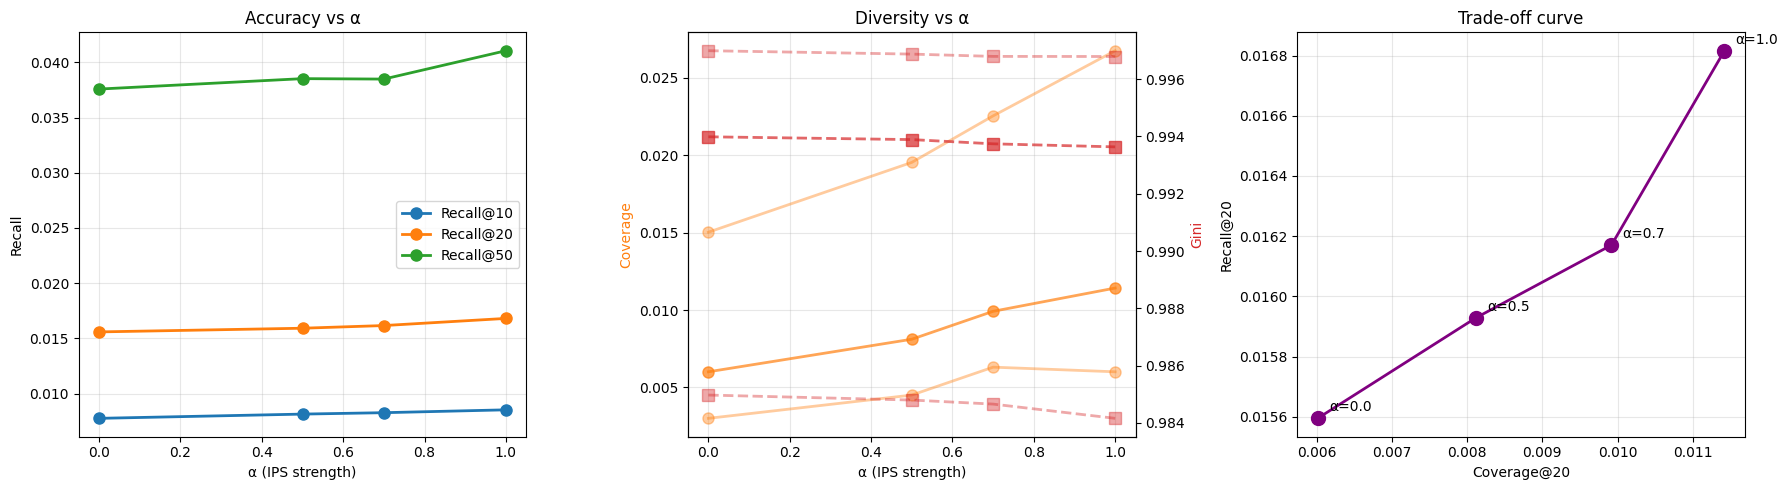

In [ ]:
# 9. Main

def main():
    big, small = load_data()
    user2idx, item2idx = build_mappings(big)
    n_users, n_items = len(user2idx), len(item2idx)
    print(f"users: {n_users:,}, items: {n_items:,}")

    # 학습 데이터 구성
    print(f"\nBuilding training pairs (watch_ratio >= {cfg.POS_THRESHOLD})...")
    pairs = build_train_pairs(big, user2idx, item2idx, cfg.POS_THRESHOLD)
    print(f"  positive pairs: {len(pairs):,}")

    if cfg.DEMO:
        n = min(cfg.DEMO_SAMPLE, len(pairs))
        idx = np.random.choice(len(pairs), n, replace=False)
        pairs = pairs[idx]
        epochs = cfg.DEMO_EPOCHS
        print(f"  [DEMO] subsampled to {len(pairs):,} pairs, {epochs} epochs")
    else:
        epochs = cfg.EPOCHS

    user_pos = build_user_positives(pairs, n_users)
    user_pos_train_dict = {u: pos for u, pos in enumerate(user_pos) if pos}

    # item별 노출 카운트 (big 전체 기반, propensity 재계산용)
    item_pop_count = np.zeros(n_items, dtype=np.float64)
    big_idx = big["video_id"].map(item2idx)
    for item_idx, c in big_idx.value_counts().items():
        item_pop_count[item_idx] = c
    item_pop_count = np.maximum(item_pop_count, 1.0)  # 0 방지

    # small_items idx
    small_items_idx = sorted({item2idx[v] for v in small["video_id"].unique()
                              if v in item2idx})
    print(f"  small_items in eval: {len(small_items_idx):,}")

    # α별로 학습 + 평가
    results = []
    for alpha in cfg.ALPHAS:
        print(f"\n{'═' * 60}")
        print(f"  α = {alpha}  {'(baseline, 무보정)' if alpha == 0 else '(IPS-debiased)'}")
        print('═' * 60)

        t0 = time.time()
        # propensity tensor
        p_np = build_propensity(item_pop_count, alpha)
        p_tensor = torch.tensor(p_np, device=device)

        # 모델 + 학습
        model = BPRMF(n_users, n_items, cfg.EMBED_DIM).to(device)
        dataset = BPRDataset(pairs, user_pos, n_items)
        loader = DataLoader(dataset, batch_size=cfg.BATCH_SIZE,
                            shuffle=True, num_workers=cfg.NUM_WORKERS,
                            pin_memory=(device.type == "cuda"))
        train_model(model, loader, p_tensor, epochs, cfg.LR, cfg.REG,
                    cfg.NORMALIZE_WEIGHTS)

        # 평가
        m = evaluate_model(model, small, user2idx, item2idx, small_items_idx,
                           user_pos_train_dict, cfg.KS, cfg.EVAL_THRESHOLD)
        m["alpha"] = alpha
        m["elapsed_sec"] = round(time.time() - t0, 1)
        results.append(m)

        # 즉시 출력
        print(f"  [{m['elapsed_sec']:.0f}s] " + "  ".join(
            f"{key}={m[key]:.4f}"
            for key in ["recall@20", "ndcg@20", "coverage@20", "gini@20"]
        ))

    # 결과 정리
    df = pd.DataFrame(results)
    cols = ["alpha"] + [f"{m}@{k}" for k in cfg.KS
                        for m in ["recall", "ndcg", "coverage", "gini"]] + ["elapsed_sec"]
    df = df[cols]
    df.to_csv(cfg.OUT_DIR / "step3_results.csv", index=False)
    print("\n" + "═" * 60)
    print("  최종 결과")
    print("═" * 60)
    print(df.to_string(index=False))
    print(f"\n[saved] {cfg.OUT_DIR / 'step3_results.csv'}")

    # 시각화
    plot_results(df, cfg.KS)

if __name__ == "__main__":
    main()

In [ ]:
# demo=TRUE

# α=0.5에서 baseline(α=0)보다 NDCG@20가 0.715 → 0.730로 올라감
# IPS 보정이 실제로 정확도까지 끌어올린다는 강한 신호
# 인기 편향 보정이 단순히 "long-tail 추천 늘리기"가 아니라 "진짜 선호를 더 잘 찾기"로 작동하는 케이스

# Coverage가 거의 평탄 + Gini가 0.99로 박힘
# 3,327개 평가 아이템 풀에서 Coverage@20 = 0.008면 전체 1,411명에게 25개 정도의 유니크 아이템만 추천한다는 뜻
# 모델이 인기 상위 몇 개로 collapse한 것
# DEMO 모드의 한계일 가능성 높음

In [ ]:
# demo=FALSE

# α↑할 때
# Recall@20: +7.8%
# NDCG@20: +8.9%
# Coverage@20: +90%
# Gini@20: 거의 변화 없음 (0.9940 → 0.9936)
# 정확도와 다양성 둘 다 좋아짐

# 추천시스템은 "정확도를 살짝 희생하고 다양성을 얻는다"인데, 우리는 정확도까지 같이 올라감
# 해석 A — 진짜 인기 편향이 강한 데이터셋
# 인기 편향이 매우 강한 데이터셋에서는, baseline BPR이 popular item에만 쏠려서 underfitting
# IPS가 long-tail item에 weight를 주면서 임베딩 공간이 더 잘 분리됨 → 정확도까지 향상! 이게 사실이라면 프로젝트의 강력한 결론
# 해석 B — 평가 셋업이 IPS에 유리하게 편향됨
# 평가를 small_items(3,327개) 안에서만 ranking하는데, small_matrix의 ground truth도 그 안에 분포
# baseline은 popular-mega-hit에 집중하는데, 그것들이 small_items에서 차지하는 비중이 작으면 baseline이 불리
# 즉 baseline이 너무 약한 거지, IPS가 진짜 좋은 게 아닐 수도 있음

# 시드 평균?
# 강한 baseline 추가?

Step 4 — Double Machine Learning (DML)

질문: 유저·아이템 특성 X를 통제했을 때, 아이템 인기도 T가
      watch_ratio Y에 미치는 순수 인과효과 θ는 얼마인가?

[셋업]

표준 DML은 (X, T, Y)를 모든 unit에 대해 관측해야 함

big_matrix만 쓰면 T=0(비노출)일 때 Y가 정의되지 않음 → DML 적용 불가

해결: small_matrix 사용 (1,411 × 3,327 = 4.7M쌍, watch_ratio 완전관측)

T는 "이진 노출"이 아니라 "아이템 인기도 강도(연속형)"로 정의

  Y = watch_ratio (small_matrix, cap=2.0)

  T = z-score(log(1 + big_matrix에서의 노출 횟수))

  X = [user features (numeric)], [video_duration]

[프로토콜]

  Stage 1:  T ~ X 학습 (XGBoost) → ê_T = T - T_hat

  Stage 2:  Y ~ X 학습 (XGBoost) → ê_Y = Y - Y_hat

  Stage 3:  ê_Y ~ ê_T 회귀 (OLS, HC1 robust SE) → θ

  보너스:    naive(통제 안 한) 회귀와 비교 → 교란 효과의 크기

5-fold cross-fitting으로 임베딩 overfit 편향 제거 (Chernozhukov et al. 2018)

XGBoost detected.
Loading data...
  small: 4,676,570 rows, big: 12,530,806 rows, user_features: (7176, 31)

Building (X, T, Y) panel...
  T (z-scored log-popularity): mean=0.000, std=1.000
  user numeric features: 25
  rows after merge: 4,676,570 (dropped 0)
  [SUBSAMPLED to 500,000]
  total features in X: 26

[Stage 1] T ~ X (predicting popularity from features)
    fold 1/5: R² = 0.0588
    fold 2/5: R² = 0.0740
    fold 3/5: R² = 0.0667
    fold 4/5: R² = 0.0702
    fold 5/5: R² = 0.0626
    overall out-of-fold R² = 0.0665
  elapsed: 68.4s

[Stage 2] Y ~ X (predicting watch_ratio from features)
    fold 1/5: R² = 0.4312
    fold 2/5: R² = 0.4305
    fold 3/5: R² = 0.4315
    fold 4/5: R² = 0.4289
    fold 5/5: R² = 0.4316
    overall out-of-fold R² = 0.4307
  elapsed: 66.1s

[Stage 3] ê_Y ~ ê_T (DML estimate)
[Naive]   Y ~ T (no covariate control)

════════════════════════════════════════════════════════════
  최종 결과
════════════════════════════════════════════════════════════
      

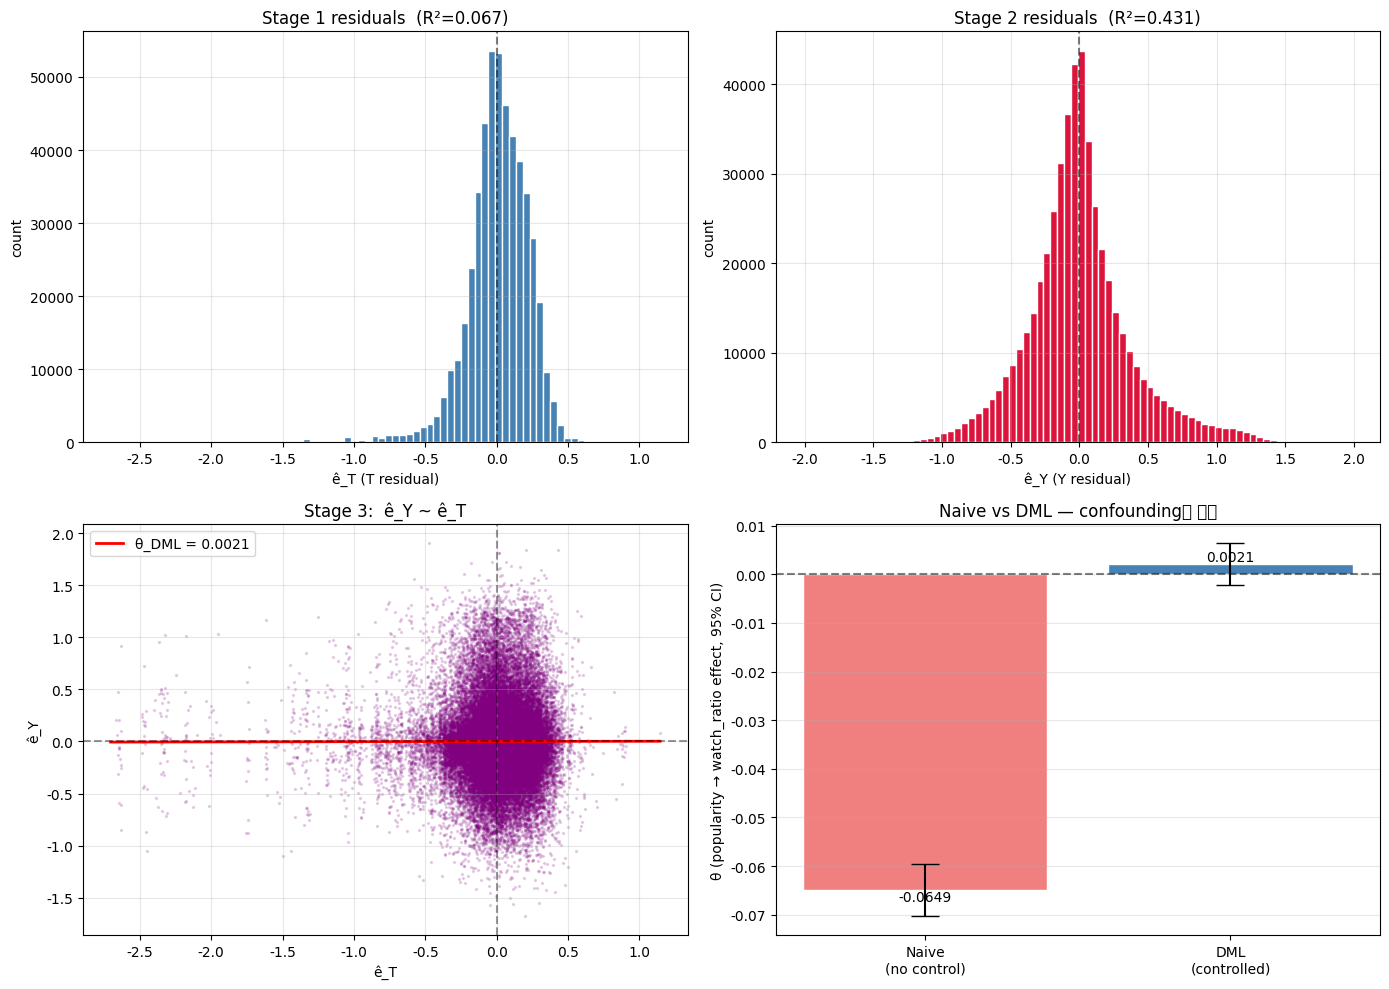

In [51]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
    USE_XGB = True
    print("XGBoost detected.")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    USE_XGB = False
    print("XGBoost not found, falling back to HistGradientBoostingRegressor.")


# ══════════════════════════════════════════════
# Config
# ══════════════════════════════════════════════
class Config:
    DATA_DIR = Path("/content/drive/MyDrive/Research/KuaiRec/data")
    OUT_DIR = Path("/content/drive/MyDrive/Research/KuaiRec/output")

    WATCH_CAP = 2.0          # Step 1에서 결정한 cap
    N_SPLITS = 5             # cross-fitting fold
    SUBSAMPLE = 500_000      # 빠른 테스트는 e.g. 500_000, 풀학습은 None

    # XGBoost 하이퍼파라미터 (모델 capacity가 적당히 있어야 nuisance가 잘 잡힘)
    XGB_PARAMS = dict(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=0,
        tree_method="hist",
    )

    SEED = 42


cfg = Config()
cfg.OUT_DIR.mkdir(exist_ok=True)
np.random.seed(cfg.SEED)


# ══════════════════════════════════════════════
# 1. 데이터 로드 & 피처 준비
# ══════════════════════════════════════════════
def load_data():
    print("Loading data...")
    small = pd.read_csv(cfg.DATA_DIR / "small_matrix.csv",
                        usecols=["user_id", "video_id", "watch_ratio"])
    big = pd.read_csv(cfg.DATA_DIR / "big_matrix.csv",
                      usecols=["user_id", "video_id", "video_duration"])
    user_features = pd.read_csv(cfg.DATA_DIR / "user_features.csv")
    print(f"  small: {len(small):,} rows, "
          f"big: {len(big):,} rows, "
          f"user_features: {user_features.shape}")
    return small, big, user_features


def prepare_user_features(uf: pd.DataFrame) -> pd.DataFrame:
    """numeric 컬럼만 추출 + NaN 0 처리."""
    num_cols = uf.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "user_id"]
    out = uf[["user_id"] + num_cols].fillna(0).copy()
    print(f"  user numeric features: {len(num_cols)}")
    return out


def build_dataset(small, big, user_features):
    """small_matrix를 기반으로 (X, T, Y) 패널 구성."""
    print("\nBuilding (X, T, Y) panel...")

    # T: 아이템 단위 인기도 (big_matrix 기준)
    item_pop = big.groupby("video_id").size().rename("exposure_count")
    T_log = np.log1p(item_pop)
    T_z = (T_log - T_log.mean()) / T_log.std()
    T_z.name = "T"
    print(f"  T (z-scored log-popularity): mean={T_z.mean():.3f}, std={T_z.std():.3f}")

    # 아이템 특성: video_duration (아이템마다 일정한 값)
    item_dur = big.groupby("video_id")["video_duration"].mean().rename("video_duration")

    # 유저 특성
    user_X = prepare_user_features(user_features)

    # 병합
    df = small.copy()
    df["Y"] = df["watch_ratio"].clip(upper=cfg.WATCH_CAP)
    df["T"] = df["video_id"].map(T_z)
    df["video_duration"] = df["video_id"].map(item_dur)
    df = df.merge(user_X, on="user_id", how="left")

    # 결측 행 제거
    before = len(df)
    df = df.dropna(subset=["T", "Y", "video_duration"])
    print(f"  rows after merge: {len(df):,} (dropped {before-len(df):,})")

    # subsample 옵션
    if cfg.SUBSAMPLE and len(df) > cfg.SUBSAMPLE:
        df = df.sample(n=cfg.SUBSAMPLE, random_state=cfg.SEED).reset_index(drop=True)
        print(f"  [SUBSAMPLED to {len(df):,}]")

    # 피처 컬럼 정의 (X에 들어갈 것들)
    feature_cols = [c for c in user_X.columns if c != "user_id"] + ["video_duration"]
    print(f"  total features in X: {len(feature_cols)}")

    return df, feature_cols


# ══════════════════════════════════════════════
# 2. ML helper — Cross-fitted residuals
# ══════════════════════════════════════════════
def make_model(seed):
    if USE_XGB:
        return xgb.XGBRegressor(**cfg.XGB_PARAMS, random_state=seed)
    return HistGradientBoostingRegressor(
        max_iter=cfg.XGB_PARAMS["n_estimators"],
        max_depth=cfg.XGB_PARAMS["max_depth"],
        learning_rate=cfg.XGB_PARAMS["learning_rate"],
        random_state=seed,
    )


def cross_fitted_predictions(X: np.ndarray, y: np.ndarray, n_splits: int, seed: int):
    """K-fold cross-fitting: out-of-fold predictions, prevent overfit bias."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_pred = np.zeros(len(y))
    fold_r2 = []
    for fold, (tr, te) in enumerate(kf.split(X)):
        model = make_model(seed=seed + fold)
        model.fit(X[tr], y[tr])
        y_pred[te] = model.predict(X[te])
        # fold-level R²
        r2 = 1 - np.var(y[te] - y_pred[te]) / np.var(y[te])
        fold_r2.append(r2)
        print(f"    fold {fold+1}/{n_splits}: R² = {r2:.4f}")
    overall_r2 = 1 - np.var(y - y_pred) / np.var(y)
    print(f"    overall out-of-fold R² = {overall_r2:.4f}")
    return y_pred, overall_r2, fold_r2


# ══════════════════════════════════════════════
# 3. DML procedure
# ══════════════════════════════════════════════
def run_dml(df: pd.DataFrame, feature_cols: list[str]):
    X = df[feature_cols].values.astype(np.float32)
    T = df["T"].values.astype(np.float32)
    Y = df["Y"].values.astype(np.float32)

    # Stage 1: T ~ X
    print("\n[Stage 1] T ~ X (predicting popularity from features)")
    t0 = time.time()
    T_hat, T_r2, T_fold_r2 = cross_fitted_predictions(X, T, cfg.N_SPLITS, cfg.SEED)
    print(f"  elapsed: {time.time()-t0:.1f}s")
    T_resid = T - T_hat

    # Stage 2: Y ~ X
    print("\n[Stage 2] Y ~ X (predicting watch_ratio from features)")
    t0 = time.time()
    Y_hat, Y_r2, Y_fold_r2 = cross_fitted_predictions(X, Y, cfg.N_SPLITS, cfg.SEED)
    print(f"  elapsed: {time.time()-t0:.1f}s")
    Y_resid = Y - Y_hat

    # Stage 3: ê_Y ~ ê_T (HC1 robust SE)
    print("\n[Stage 3] ê_Y ~ ê_T (DML estimate)")
    XX = sm.add_constant(T_resid)
    res_dml = sm.OLS(Y_resid, XX).fit(cov_type="HC1")
    theta_dml = res_dml.params[1]
    se_dml = res_dml.bse[1]
    ci_dml = res_dml.conf_int(alpha=0.05)[1]
    pval_dml = res_dml.pvalues[1]

    # Naive 비교: Y ~ T (X 통제 없음)
    print("[Naive]   Y ~ T (no covariate control)")
    XX_naive = sm.add_constant(T)
    res_naive = sm.OLS(Y, XX_naive).fit(cov_type="HC1")
    theta_naive = res_naive.params[1]
    se_naive = res_naive.bse[1]
    ci_naive = res_naive.conf_int(alpha=0.05)[1]

    return {
        "T_resid": T_resid, "Y_resid": Y_resid,
        "T_hat": T_hat, "Y_hat": Y_hat,
        "T_r2": T_r2, "Y_r2": Y_r2,
        "theta_dml": theta_dml, "se_dml": se_dml,
        "ci_dml_low": ci_dml[0], "ci_dml_high": ci_dml[1],
        "pval_dml": pval_dml,
        "theta_naive": theta_naive, "se_naive": se_naive,
        "ci_naive_low": ci_naive[0], "ci_naive_high": ci_naive[1],
        "T": T, "Y": Y,
    }


# ══════════════════════════════════════════════
# 4. Visualization
# ══════════════════════════════════════════════
def plot_diagnostics(r: dict):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # (a) T residual 분포
    ax = axes[0, 0]
    ax.hist(r["T_resid"], bins=80, color="steelblue", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("ê_T (T residual)")
    ax.set_ylabel("count")
    ax.set_title(f"Stage 1 residuals  (R²={r['T_r2']:.3f})")
    ax.grid(True, alpha=0.3)

    # (b) Y residual 분포
    ax = axes[0, 1]
    ax.hist(r["Y_resid"], bins=80, color="crimson", edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("ê_Y (Y residual)")
    ax.set_ylabel("count")
    ax.set_title(f"Stage 2 residuals  (R²={r['Y_r2']:.3f})")
    ax.grid(True, alpha=0.3)

    # (c) ê_Y vs ê_T scatter + DML fit line
    ax = axes[1, 0]
    # 4.7M 점 다 그리면 무거우니 sample
    n = min(50_000, len(r["T_resid"]))
    idx = np.random.choice(len(r["T_resid"]), n, replace=False)
    ax.scatter(r["T_resid"][idx], r["Y_resid"][idx], s=2, alpha=0.15,
               color="purple")
    # DML fit line
    xline = np.linspace(r["T_resid"].min(), r["T_resid"].max(), 50)
    yline = r["theta_dml"] * xline
    ax.plot(xline, yline, "r-", linewidth=2,
            label=f"θ_DML = {r['theta_dml']:.4f}")
    ax.axhline(0, color="black", linestyle="--", alpha=0.4)
    ax.axvline(0, color="black", linestyle="--", alpha=0.4)
    ax.set_xlabel("ê_T")
    ax.set_ylabel("ê_Y")
    ax.set_title("Stage 3:  ê_Y ~ ê_T")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (d) Naive vs DML θ 비교 (95% CI)
    ax = axes[1, 1]
    methods = ["Naive\n(no control)", "DML\n(controlled)"]
    thetas = [r["theta_naive"], r["theta_dml"]]
    errs = [
        [r["theta_naive"] - r["ci_naive_low"], r["ci_naive_high"] - r["theta_naive"]],
        [r["theta_dml"] - r["ci_dml_low"], r["ci_dml_high"] - r["theta_dml"]],
    ]
    errs = np.array(errs).T
    colors = ["lightcoral", "steelblue"]
    bars = ax.bar(methods, thetas, yerr=errs, capsize=10,
                  color=colors, edgecolor="white")
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    for bar, val in zip(bars, thetas):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f"{val:.4f}", ha="center",
                va="bottom" if val > 0 else "top")
    ax.set_ylabel("θ (popularity → watch_ratio effect, 95% CI)")
    ax.set_title("Naive vs DML — confounding의 크기")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    fig.savefig(cfg.OUT_DIR / "06_dml_diagnostics.png", dpi=120)
    print(f"\n[saved] {cfg.OUT_DIR / '06_dml_diagnostics.png'}")
    plt.show()


# ══════════════════════════════════════════════
# 5. 결과 정리 & 해석
# ══════════════════════════════════════════════
def summarize(r: dict):
    print("\n" + "═" * 60)
    print("  최종 결과")
    print("═" * 60)

    summary = pd.DataFrame([
        {
            "method": "Naive (no control)",
            "theta": r["theta_naive"],
            "se": r["se_naive"],
            "ci_low": r["ci_naive_low"],
            "ci_high": r["ci_naive_high"],
        },
        {
            "method": "DML (X-controlled)",
            "theta": r["theta_dml"],
            "se": r["se_dml"],
            "ci_low": r["ci_dml_low"],
            "ci_high": r["ci_dml_high"],
            "pval": r["pval_dml"],
        },
    ])
    print(summary.to_string(index=False))
    summary.to_csv(cfg.OUT_DIR / "step4_dml_results.csv", index=False)
    print(f"\n[saved] {cfg.OUT_DIR / 'step4_dml_results.csv'}")

    # 자동 해석 보조
    confounding = r["theta_naive"] - r["theta_dml"]
    pct_explained = (
        100 * (1 - r["theta_dml"] / r["theta_naive"]) if r["theta_naive"] != 0 else 0
    )

def main():
    small, big, user_features = load_data()
    df, feature_cols = build_dataset(small, big, user_features)
    r = run_dml(df, feature_cols)
    summarize(r)
    plot_diagnostics(r)


if __name__ == "__main__":
    main()

In [ ]:
# Naive θ = -0.0649 / 매우 유의
#  → "X를 통제 안 했을 때" T가 1 SD 증가할 때 Y의 변화량
# DML θ   = +0.0021  (95% CI: [-0.0023, +0.0065]) / p-value=0.349 유의하지 않음
#  → "X를 통제했을 때" T의 순수 인과효과
# 차이 = -0.0670  (+103.2% 가 X로 설명됨)

# Step 1에서 발견했던 "인기도 ↔ watch_ratio 음의 상관(−0.06)"은 거의 100% confounding
# user/item 특성을 통제하니 인과효과는 0과 통계적으로 구분되지 않는다 (p=0.35, CI가 0을 포함)

# "인기 영상은 덜 만족스럽다"는 직관 → 틀렸다
# 인기도 자체엔 인과효과 없음
# 다만 인기 영상은 평균적으로 어떤 종류의 user/item 특성을 가졌고, 그 특성이 watch_ratio와 약하게 음의 상관 → 그래서 marginal correlation에선 음의 상관처럼 보였던 것

In [ ]:
#[Stage 1·2 nuisance R²]
#  T ~ X : R² = 0.067  (낮음 → 인기도는 특성과 거의 무관)
#  Y ~ X : R² = 0.431  (높음 → 특성으로 시청률 잘 예측됨)

# Y는 X로 잘 설명되지만 T는 X로 거의 설명 안됨
# Y(시청률)는 user/item 특성에 강하게 의존
# T(인기도)는 그 특성들과 거의 무관하게 결정됨 (랜덤 노출 비슷)
# 즉, T는 통제 후엔 효과가 사라진 것, 추천시스템의 노출 패턴이 user 특성에 크게 좌우되지 않는다는 뜻

# 아 그래서 !!! Step 3에서 IPS-BPR이 baseline보다 정확도까지 올렸던 이유가 이걸로 설명됨
# 인기도 자체엔 인과효과가 없으므로, 인기도 신호를 강하게 따라가는 baseline은 신호 없는 방향으로 학습한 셈
# IPS가 그 신호를 약화시켜주니 더 의미 있는 패턴에 집중하게 됨 → 정확도까지 같이 올라감